# Roy et al. BRDF normalization with openEO `predict_onnx`

Minimal example of using `roy_brdf.onnx` (hosted in this repository) to normalize
Sentinel-2 surface reflectance to nadir viewing geometry (NBAR).

Context: [ESA-APEx/apex_algorithms#687](https://github.com/ESA-APEx/apex_algorithms/issues/687)

## What the model does

A surface does not reflect sunlight equally in all directions: a forest looks
brighter when the satellite views it from the same side as the sun (backscatter)
than from the opposite side. The same patch of ground therefore yields different
reflectance depending on the sun and view geometry at acquisition time, which
complicates comparing images from different dates or sensors.

The Roy et al. (2016/2017) c-factor method multiplies each pixel by a per-band
factor computed from the Ross-Thick and Li-Sparse BRDF kernels, to estimate what the
pixel would have looked like at a fixed reference geometry. The result is **NBAR**
(Nadir BRDF-Adjusted Reflectance).

The model is a frozen analytical function of the angles - no trained weights - so it
is a good fit for ONNX.

## Prerequisites

Just `openeo`, plus an account on Copernicus Data Space Ecosystem (CDSE):

```bash
pip install openeo
```

## The model contract

`predict_onnx` passes the cube's bands to the model positionally, in the same order
they appear in the cube. There is no way to bind band names to channels, so the
order below is a **silent contract**: if the cube is loaded with the bands in a
different order, the model still runs and quietly produces wrong numbers.

**Input `(11, H, W)` float64** - H and W are fixed at 32 in this model
(the backend retiles your cube to match):

| # | channel | meaning |
|---|---------|---------|
| 0-5 | `B02 B03 B04 B8A B11 B12` | surface reflectance |
| 6 | `sunZenithAngles` | sun zenith angle [deg] |
| 7 | `viewZenithMean` | view zenith angle [deg] |
| 8 | `sunAzimuthAngles` | sun azimuth [deg] |
| 9 | `viewAzimuthMean` | view azimuth [deg] |
| 10 | `theta_s` | per-scene reference sun zenith [deg] |

**Output `(6, H, W)` float64** - corrected reflectance for `B02 B03 B04 B8A B11 B12`.

Two things to know:

- **`theta_s` is an input channel.** `predict_onnx` has no `context` parameter, so
  the per-scene reference angle has to be delivered as data. It is derived from the
  scene-center latitude, and this notebook builds it in the process graph.
- **Only 6 bands are supported**, the ones with a MODIS spectral analogue (which is
  what the Roy coefficients are defined for).

In [1]:
import openeo

connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


## Configuration

Change the area and dates to your own. Keep the area small while testing - the job
cost scales with it.

In [2]:
# The 6 corrected bands, in the exact order the model expects.
REFLECTANCE_BANDS = ["B02", "B03", "B04", "B8A", "B11", "B12"]

# The 4 angle bands, also in the model's expected order.
ANGLE_BANDS = ["sunZenithAngles", "viewZenithMean", "sunAzimuthAngles", "viewAzimuthMean"]

# NOTE: this concatenation IS the model's channel order. Do not reorder.
LOAD_BANDS = REFLECTANCE_BANDS + ANGLE_BANDS

spatial_extent = {"west": 5.05, "south": 51.21, "east": 5.10, "north": 51.23, "crs": "EPSG:4326"}
temporal_extent = ("2022-05-01", "2022-05-30")

MODEL_URL = "https://raw.githubusercontent.com/minaskar/openeo-brdf-onnx/main/roy_brdf.onnx"

load_bands_ordered_correctly = True  # assertion guard below, see README

## Compute `theta_s` for the scene

Roy's method normalizes every pixel to one fixed reference geometry for the whole
scene. That reference sun zenith angle `theta_s` is estimated from the scene-center
latitude with the polynomial from sen2like (their eq. 4) - the same one baked into
the reference implementation.

The polynomial is repeated here in plain Python so this notebook needs no extra
dependencies.

In [3]:
def mean_sun_zenith(scene_center_lat):
    """Mean sun zenith angle [deg] from scene-center latitude (sen2like eq. 4)."""
    return (
        6.15e-11 * scene_center_lat**6
        - 1.95e-09 * scene_center_lat**5
        - 9.48e-07 * scene_center_lat**4
        + 2.40e-05 * scene_center_lat**3
        + 0.01187 * scene_center_lat**2
        - 0.1272 * scene_center_lat
        + 31.0076
    )


scene_center_lat = (spatial_extent["south"] + spatial_extent["north"]) / 2
theta_s = float(mean_sun_zenith(scene_center_lat))
print(f"scene center latitude {scene_center_lat} -> theta_s = {theta_s:.4f} deg")

scene center latitude 51.22 -> theta_s = 52.7565 deg


## Load the collection

`SENTINEL2_L2A` is atmospherically corrected surface reflectance, which is what the
BRDF model expects (not top-of-atmosphere signal).

The angle bands are provided by the backend on a coarse grid (Sentinel-2 angles are
only known per detector, roughly 5 km) and are resampled onto the reflectance grid.
That is an approximation inherent to the data, not to this model.

In [4]:
cube = connection.load_collection(
    "SENTINEL2_L2A",
    bands=LOAD_BANDS,
    spatial_extent=spatial_extent,
    temporal_extent=temporal_extent,
    max_cloud_cover=50,
)

assert LOAD_BANDS == REFLECTANCE_BANDS + ANGLE_BANDS
print("loading bands in model order:", LOAD_BANDS)

loading bands in model order: ['B02', 'B03', 'B04', 'B8A', 'B11', 'B12', 'sunZenithAngles', 'viewZenithMean', 'sunAzimuthAngles', 'viewAzimuthMean']


## Append `theta_s` as an 11th band

This is the one part that needs a little machinery. `add_dimension` can only create a
dimension with a single label, so the 11th channel is built in three steps:

1. reduce the cube along `bands` to get a single-band cube (we only need its shape),
2. turn it into a constant field equal to `theta_s`,
3. add a `bands` dimension labelled `theta_s` and merge it with the original cube.

Because the band labels are disjoint, `merge_cubes` concatenates them without needing
an overlap resolver, giving exactly `[...10 bands..., theta_s]`.

In [5]:
# A constant (t, y, x) field holding theta_s, then labelled as an extra band.
theta_band = cube.reduce_dimension(dimension="bands", reducer="first") * 0 + theta_s
theta_band = theta_band.add_dimension(name="bands", label="theta_s", type="bands")

cube_11 = cube.merge_cubes(theta_band)
cube_11

## Run the model

`predict_onnx` fetches the model from the URL and runs it on each tile.

Note: call it as `cube_11.process(...)` with `data=cube_11` passed explicitly. The
generic `DataCube.process()` does *not* wire the cube in as `data` the way helpers
like `apply_dimension` do, and omitting it produces a graph with no input.

ONNX inference is not available for synchronous downloads, so this runs as a batch job.

In [6]:
nbar_cube = cube_11.process("predict_onnx", data=cube_11, model=MODEL_URL)

# Confirm the graph actually links the input cube.
node = [n for n in nbar_cube.flat_graph().values() if n["process_id"] == "predict_onnx"][0]
assert "data" in node["arguments"], "predict_onnx has no data input!"
print("predict_onnx arguments:", sorted(node["arguments"]))

job = nbar_cube.create_job(title="Roy BRDF NBAR via predict_onnx")
print("job:", job.job_id)
job.start_and_wait()
print("status:", job.status())
job.get_results().download_files("nbar_output")
print("downloaded to nbar_output/")

predict_onnx arguments: ['data', 'model']


job: j-26100212162146aaab1dcb50dd27fcd2
0:00:00 Job 'j-26100212162146aaab1dcb50dd27fcd2': send 'start'


0:00:03 Job 'j-26100212162146aaab1dcb50dd27fcd2': created (progress 0%)


0:00:08 Job 'j-26100212162146aaab1dcb50dd27fcd2': queued (progress 0%)


0:00:14 Job 'j-26100212162146aaab1dcb50dd27fcd2': queued (progress 0%)


...

0:01:19 Job 'j-26100212162146aaab1dcb50dd27fcd2': running (progress N/A)


0:01:43 Job 'j-26100212162146aaab1dcb50dd27fcd2': running (progress N/A)


0:02:13 Job 'j-26100212162146aaab1dcb50dd27fcd2': finished (progress 100%)


status: finished


downloaded to nbar_output/


## Inspect the result

The backend returns one GeoTIFF per acquisition (GeoTIFF cannot store a time
dimension), each with 6 bands in model order.

output files: ['nbar_output/openEO_2022-05-02Z.tif', 'nbar_output/openEO_2022-05-15Z.tif', 'nbar_output/openEO_2022-05-22Z.tif']
6 bands, 357x233, dtype float64


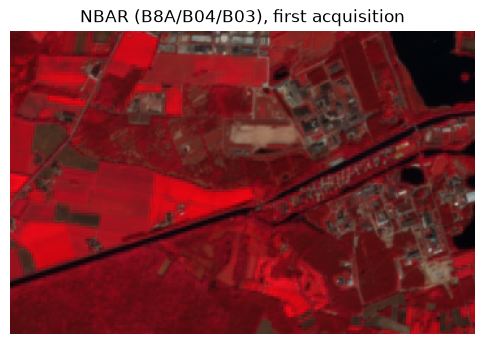

In [7]:
import glob

import matplotlib.pyplot as plt
import rasterio

files = sorted(glob.glob("nbar_output/openEO_*.tif"))
print("output files:", files)

if files:
    with rasterio.open(files[0]) as src:
        print(f"{src.count} bands, {src.width}x{src.height}, dtype {src.dtypes[0]}")
        arr = src.read()

    # False-colour composite (B8A, B04, B03) for a quick look.
    rgb = arr[[3, 2, 1]]
    rgb = rgb / max(1e-9, rgb.max())
    plt.figure(figsize=(6, 6))
    plt.imshow(rgb.transpose(1, 2, 0))
    plt.title("NBAR (B8A/B04/B03), first acquisition")
    plt.axis("off")
    plt.show()

## Caveats

- **Band order is positional and unguarded.** Nothing checks that channel 0 really is
  `B02`. Load the bands in the order above, or the numbers will be wrong silently.
- **Fixed tile size.** This model is compiled for 32x32; the backend retiles the cube
  to match. A different size needs a rebuilt model.
- **Only 6 bands** with MODIS analogues are corrected. B01, B05-B07, B09 and the
  atmospheric bands are not covered.
- **`theta_s` is per scene.** It is derived from the scene-center latitude, so a very
  large or high-latitude area may warrant recomputing it per sub-scene.
- **Angles are backend-resampled.** Compare to sen2like, results will be close but
  not identical, because sen2like resamples the 5 km angle grid natively.
- **The +/-20% clamp** on the correction is inherited from sen2like, not from Roy
  et al. It exists to suppress physically implausible corrections.

## Attribution

Method: Roy et al. (2016, 2017). Reference implementation: the sen2like project
(ESA / CS Group), Apache-2.0.